In [1]:
# ============================================================
# STEP 1 — Load & Explore the Data (EDA)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')
# Set plot style globally
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# ============================================================
# 1.1 — Load the dataset
# ============================================================
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("✅ Dataset loaded successfully")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

✅ Dataset loaded successfully
   Shape: 7043 rows × 21 columns



In [3]:
# ============================================================
# 1.2 — View all column names & data types
# ============================================================
print("📋 Column Names & Data Types:")
print(df.dtypes)
print()

📋 Column Names & Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object



In [4]:
# ============================================================
# 1.3 — Preview first 5 rows
# ============================================================
print("👀 First 5 rows:")
print(df.head())
print()

👀 First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies     

In [5]:
# ============================================================
# 1.4 — Basic statistics
# ============================================================
print("📊 Basic Statistics:")
print(df.describe())
print()

📊 Basic Statistics:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000



In [6]:
# ============================================================
# 1.5 — Check missing values
# ============================================================
print("🔍 Missing Values:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("   ✅ No missing values found")
else:
    print(missing)
print()

🔍 Missing Values:
   ✅ No missing values found



🎯 Churn Distribution:
No     5174
Yes    1869
Name: Churn, dtype: int64

   Not Churned : 73.5%
   Churned     : 26.5%



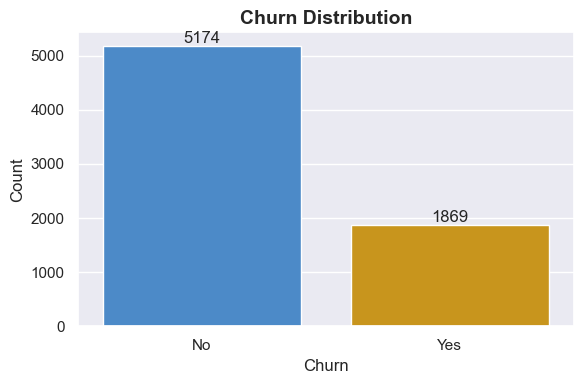

   📸 Saved: churn_distribution.png



In [7]:
# ============================================================
# 1.6 — Check target variable distribution (Churn)
# ============================================================
print("🎯 Churn Distribution:")
print(df['Churn'].value_counts())
print()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(f"   Not Churned : {churn_pct['No']:.1f}%")
print(f"   Churned     : {churn_pct['Yes']:.1f}%")
print()

# Plot churn distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette=['#378ADD', '#E5A000'])
ax.bar_label(ax.containers[0], fmt='%d')
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()
print("   📸 Saved: churn_distribution.png\n")

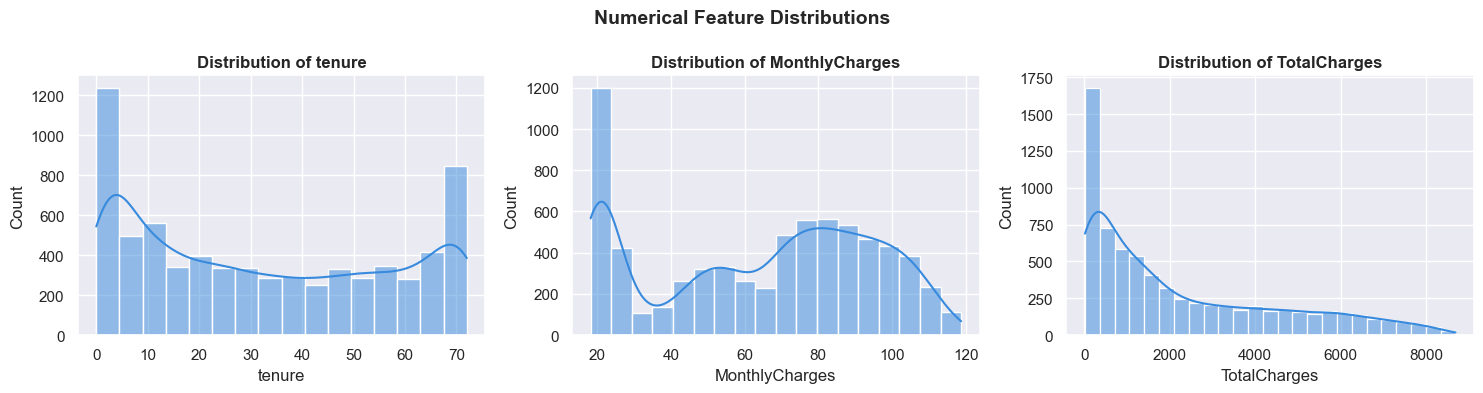

   📸 Saved: numerical_distributions.png



In [8]:
# ============================================================
# 1.7 — Numerical feature distributions
# ============================================================
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    # TotalCharges is stored as object — convert first
    df[col] = pd.to_numeric(df[col], errors='coerce')
    sns.histplot(df[col], ax=axes[i], kde=True, color='#378ADD')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150)
plt.show()
print("   📸 Saved: numerical_distributions.png\n")

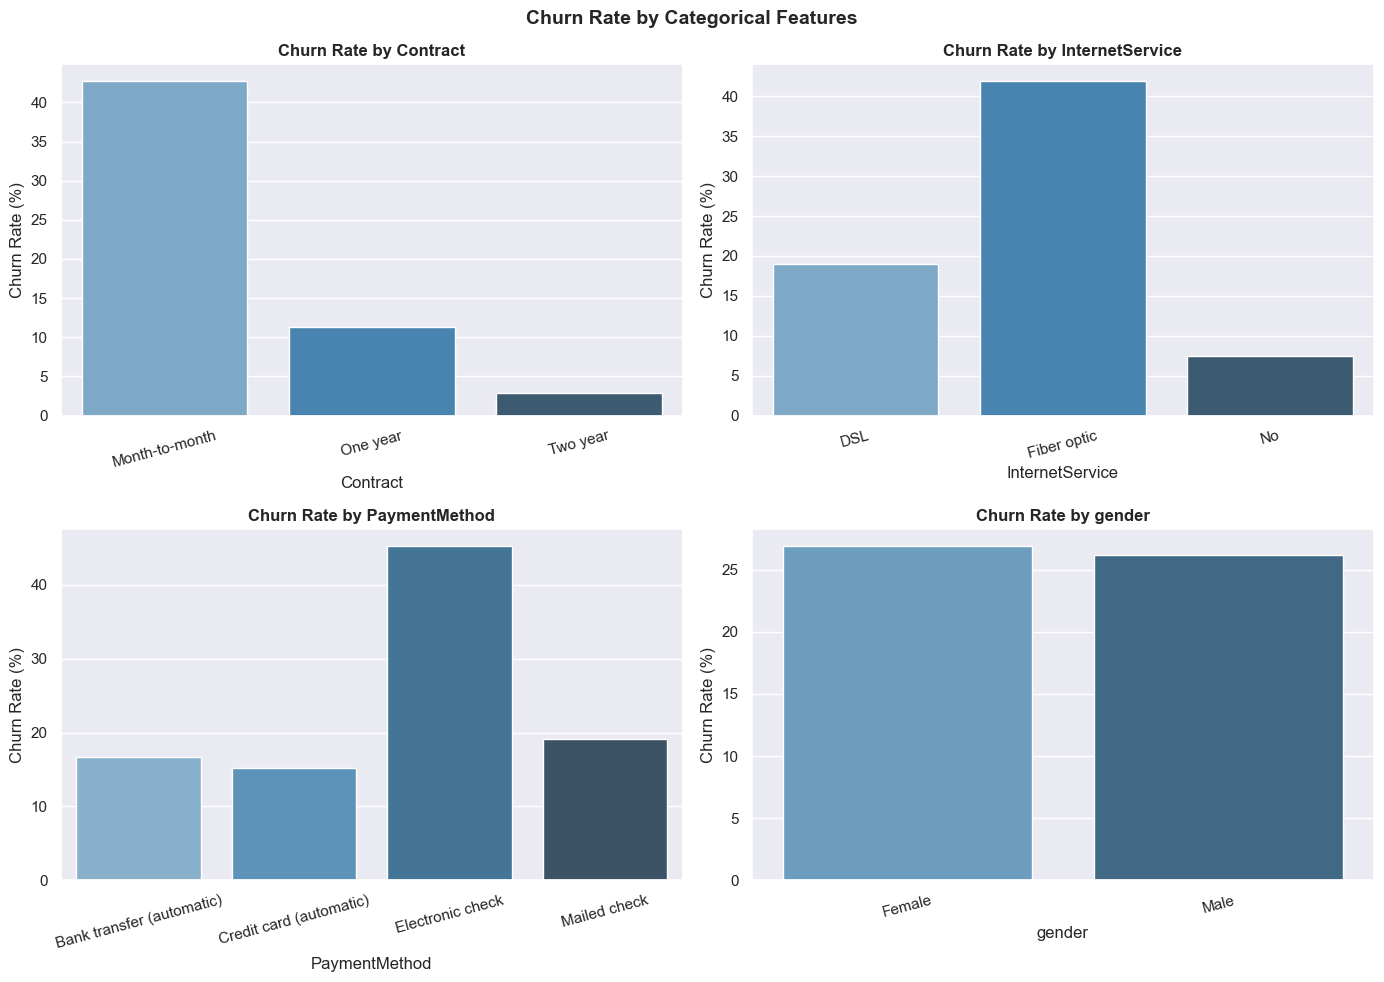

   📸 Saved: churn_by_categories.png



In [9]:
# ============================================================
# 1.8 — Churn rate by key categorical features
# ============================================================
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn Rate (%)']
    sns.barplot(x=col, y='Churn Rate (%)', data=churn_rate,
                ax=axes[i], palette='Blues_d')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_categories.png', dpi=150)
plt.show()
print("   📸 Saved: churn_by_categories.png\n")

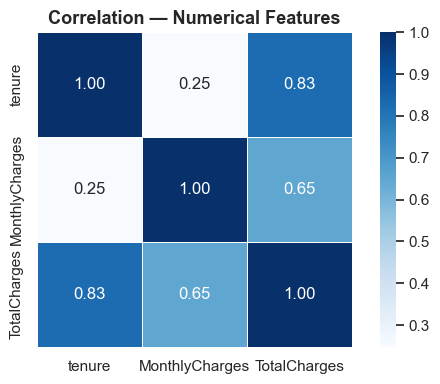

   📸 Saved: correlation_heatmap.png



In [10]:

# ============================================================
# 1.9 — Correlation heatmap (numerical only)
# ============================================================
plt.figure(figsize=(6, 4))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, square=True)
plt.title('Correlation — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("   📸 Saved: correlation_heatmap.png\n")

In [11]:
# ============================================================
# 1.10 — EDA Summary
# ============================================================
print("=" * 50)
print("✅ EDA COMPLETE — Key Observations")
print("=" * 50)
print(f"  Total customers    : {len(df)}")
print(f"  Churned customers  : {(df['Churn'] == 'Yes').sum()}")
print(f"  Churn rate         : {churn_pct['Yes']:.1f}%")
print(f"  Avg Monthly Charge : ${df['MonthlyCharges'].mean():.2f}")
print(f"  Avg Tenure         : {df['tenure'].mean():.1f} months")
print(f"  TotalCharges nulls : {df['TotalCharges'].isnull().sum()} (from conversion)")
print()
print("  📌 Note: TotalCharges had blank strings converted to NaN")
print("  📌 These will be handled in Step 2 — Data Cleaning")

✅ EDA COMPLETE — Key Observations
  Total customers    : 7043
  Churned customers  : 1869
  Churn rate         : 26.5%
  Avg Monthly Charge : $64.76
  Avg Tenure         : 32.4 months
  TotalCharges nulls : 11 (from conversion)

  📌 Note: TotalCharges had blank strings converted to NaN
  📌 These will be handled in Step 2 — Data Cleaning


In [12]:
# ============================================================
# STEP 2 — Data Cleaning, Preprocessing & sklearn Pipeline
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

In [13]:
# ============================================================
# 2.1 — Reload dataset fresh
# ============================================================
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("✅ Dataset reloaded")
print(f"   Shape: {df.shape}\n")

✅ Dataset reloaded
   Shape: (7043, 21)



In [14]:
# ============================================================
# 2.2 — Drop irrelevant column
# ============================================================
df.drop(columns=['customerID'], inplace=True)
print("🗑️  Dropped: customerID (not useful for prediction)\n")

🗑️  Dropped: customerID (not useful for prediction)



In [15]:
# ============================================================
# 2.3 — Fix TotalCharges (blank strings → NaN → fill)
# ============================================================
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

null_count = df['TotalCharges'].isnull().sum()
print(f"🔧 TotalCharges — {null_count} blank values found")

# Fill NaN with median (safer than mean for skewed data)
median_val = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_val, inplace=True)
print(f"   Filled with median: ${median_val:.2f}")
print(f"   Nulls remaining: {df['TotalCharges'].isnull().sum()}\n")

🔧 TotalCharges — 11 blank values found
   Filled with median: $1397.47
   Nulls remaining: 0



In [16]:
# ============================================================
# 2.4 — Encode target variable (Churn: Yes=1, No=0)
# ============================================================
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("🎯 Target encoded — Churn: Yes=1, No=0")
print(f"   Churned    : {df['Churn'].sum()} customers")
print(f"   Not Churned: {(df['Churn'] == 0).sum()} customers\n")

🎯 Target encoded — Churn: Yes=1, No=0
   Churned    : 1869 customers
   Not Churned: 5174 customers



In [17]:
# ============================================================
# 2.5 — Fix SeniorCitizen (already 0/1 but confirm)
# ============================================================
print("👴 SeniorCitizen value counts:")
print(df['SeniorCitizen'].value_counts())
print()

👴 SeniorCitizen value counts:
0    5901
1    1142
Name: SeniorCitizen, dtype: int64



In [18]:
# ============================================================
# 2.6 — Identify column types for pipeline
# ============================================================
# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identify numerical and categorical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

cat_cols = [col for col in X.columns
            if col not in num_cols and col != 'SeniorCitizen']

print("📋 Column Types Identified:")
print(f"   Numerical  ({len(num_cols)}) : {num_cols}")
print(f"   Categorical({len(cat_cols)}) : {cat_cols}")
print()

📋 Column Types Identified:
   Numerical  (3) : ['tenure', 'MonthlyCharges', 'TotalCharges']
   Categorical(15) : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']



In [19]:
# ============================================================
# 2.7 — Build sklearn Pipeline (this is what your resume means
#        by "ML-ready pipelines")
# ============================================================

# Numerical pipeline: impute → scale
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute → one-hot encode
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both into one ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
],  remainder='passthrough')  # keeps SeniorCitizen as-is

print("✅ sklearn Pipeline built:")
print("   Numerical  → SimpleImputer (median) → StandardScaler")
print("   Categorical→ SimpleImputer (mode)   → OneHotEncoder")
print("   SeniorCitizen → passed through as-is\n")


✅ sklearn Pipeline built:
   Numerical  → SimpleImputer (median) → StandardScaler
   Categorical→ SimpleImputer (mode)   → OneHotEncoder
   SeniorCitizen → passed through as-is



In [20]:
# ============================================================
# 2.8 — Train/Test Split
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ensures same churn ratio in both splits
)

print("✂️  Train/Test Split (80/20):")
print(f"   X_train: {X_train.shape}")
print(f"   X_test : {X_test.shape}")
print(f"   Train churn rate: {y_train.mean()*100:.1f}%")
print(f"   Test churn rate : {y_test.mean()*100:.1f}%\n")

✂️  Train/Test Split (80/20):
   X_train: (5634, 19)
   X_test : (1409, 19)
   Train churn rate: 26.5%
   Test churn rate : 26.5%



In [21]:
# ============================================================
# 2.9 — Fit & Transform the data through pipeline
# ============================================================
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("⚙️  Data processed through pipeline:")
print(f"   X_train_processed shape: {X_train_processed.shape}")
print(f"   X_test_processed shape : {X_test_processed.shape}\n")

⚙️  Data processed through pipeline:
   X_train_processed shape: (5634, 45)
   X_test_processed shape : (1409, 45)



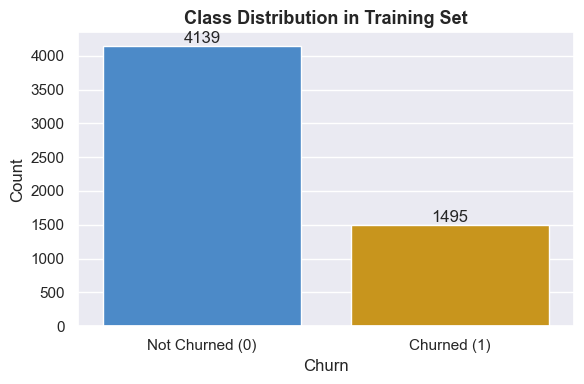

📸 Saved: class_imbalance.png



In [22]:
# ============================================================
# 2.10 — Visualize class imbalance clearly
# ============================================================
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_train, palette=['#378ADD', '#E5A000'])
ax.bar_label(ax.containers[0], fmt='%d')
plt.title('Class Distribution in Training Set', fontsize=13, fontweight='bold')
plt.xticks([0, 1], ['Not Churned (0)', 'Churned (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150)
plt.show()
print("📸 Saved: class_imbalance.png\n")


In [23]:
# ============================================================
# 2.11 — Save preprocessor for reuse in later steps
# ============================================================
import joblib
joblib.dump(preprocessor, 'preprocessor.pkl')
print("💾 Saved: preprocessor.pkl (reused in Steps 4 & 5)\n")

💾 Saved: preprocessor.pkl (reused in Steps 4 & 5)



In [24]:
# ============================================================
# 2.12 — Step Summary
# ============================================================
print("=" * 50)
print("✅ STEP 2 COMPLETE — Ready for Feature Engineering")
print("=" * 50)
print(f"  Cleaned rows        : {len(df)}")
print(f"  Features (X)        : {X.shape[1]} columns")
print(f"  Target (y)          : Churn (0 or 1)")
print(f"  Training samples    : {X_train.shape[0]}")
print(f"  Test samples        : {X_test.shape[0]}")
print(f"  Processed features  : {X_train_processed.shape[1]} (after encoding)")
print()
print("  Variables ready for Step 3:")
print("  ✔ X_train, X_test, y_train, y_test")
print("  ✔ X_train_processed, X_test_processed")
print("  ✔ preprocessor (saved as .pkl)")

✅ STEP 2 COMPLETE — Ready for Feature Engineering
  Cleaned rows        : 7043
  Features (X)        : 19 columns
  Target (y)          : Churn (0 or 1)
  Training samples    : 5634
  Test samples        : 1409
  Processed features  : 45 (after encoding)

  Variables ready for Step 3:
  ✔ X_train, X_test, y_train, y_test
  ✔ X_train_processed, X_test_processed
  ✔ preprocessor (saved as .pkl)


In [25]:
# ============================================================
# STEP 3 — Feature Engineering & Selection
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

In [26]:
# ============================================================
# 3.1 — Engineer new features from existing columns
# ============================================================
print("🔧 Engineering new features...\n")

# Feature 1: Avg Monthly Spend (TotalCharges / tenure)
# Customers with high avg spend may churn more
df['Avg_Monthly_Spend'] = np.where(
    df['tenure'] == 0,
    df['MonthlyCharges'],
    df['TotalCharges'] / df['tenure']
)

# Feature 2: Tenure Group (bin tenure into ranges)
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1 yr', '1-2 yr', '2-4 yr', '4-6 yr']
)

# Feature 3: Number of services subscribed
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]
df['Total_Services'] = df[service_cols].apply(
    lambda row: sum(1 for val in row if val == 'Yes'), axis=1
)

# Feature 4: Is long term contract (Month-to-month = 0, else = 1)
df['Is_LongTerm_Contract'] = df['Contract'].apply(
    lambda x: 0 if x == 'Month-to-month' else 1
)

# Feature 5: Has premium services (both streaming + security)
df['Has_Premium_Services'] = (
    (df['StreamingTV'] == 'Yes') &
    (df['StreamingMovies'] == 'Yes') &
    (df['OnlineSecurity'] == 'Yes')
).astype(int)

print("✅ New features created:")
print("   ✔ Avg_Monthly_Spend   — avg spend per month")
print("   ✔ Tenure_Group        — binned tenure ranges")
print("   ✔ Total_Services      — count of subscribed services")
print("   ✔ Is_LongTerm_Contract— 0=monthly, 1=yearly/2yr")
print("   ✔ Has_Premium_Services— has streaming + security\n")

🔧 Engineering new features...

✅ New features created:
   ✔ Avg_Monthly_Spend   — avg spend per month
   ✔ Tenure_Group        — binned tenure ranges
   ✔ Total_Services      — count of subscribed services
   ✔ Is_LongTerm_Contract— 0=monthly, 1=yearly/2yr
   ✔ Has_Premium_Services— has streaming + security



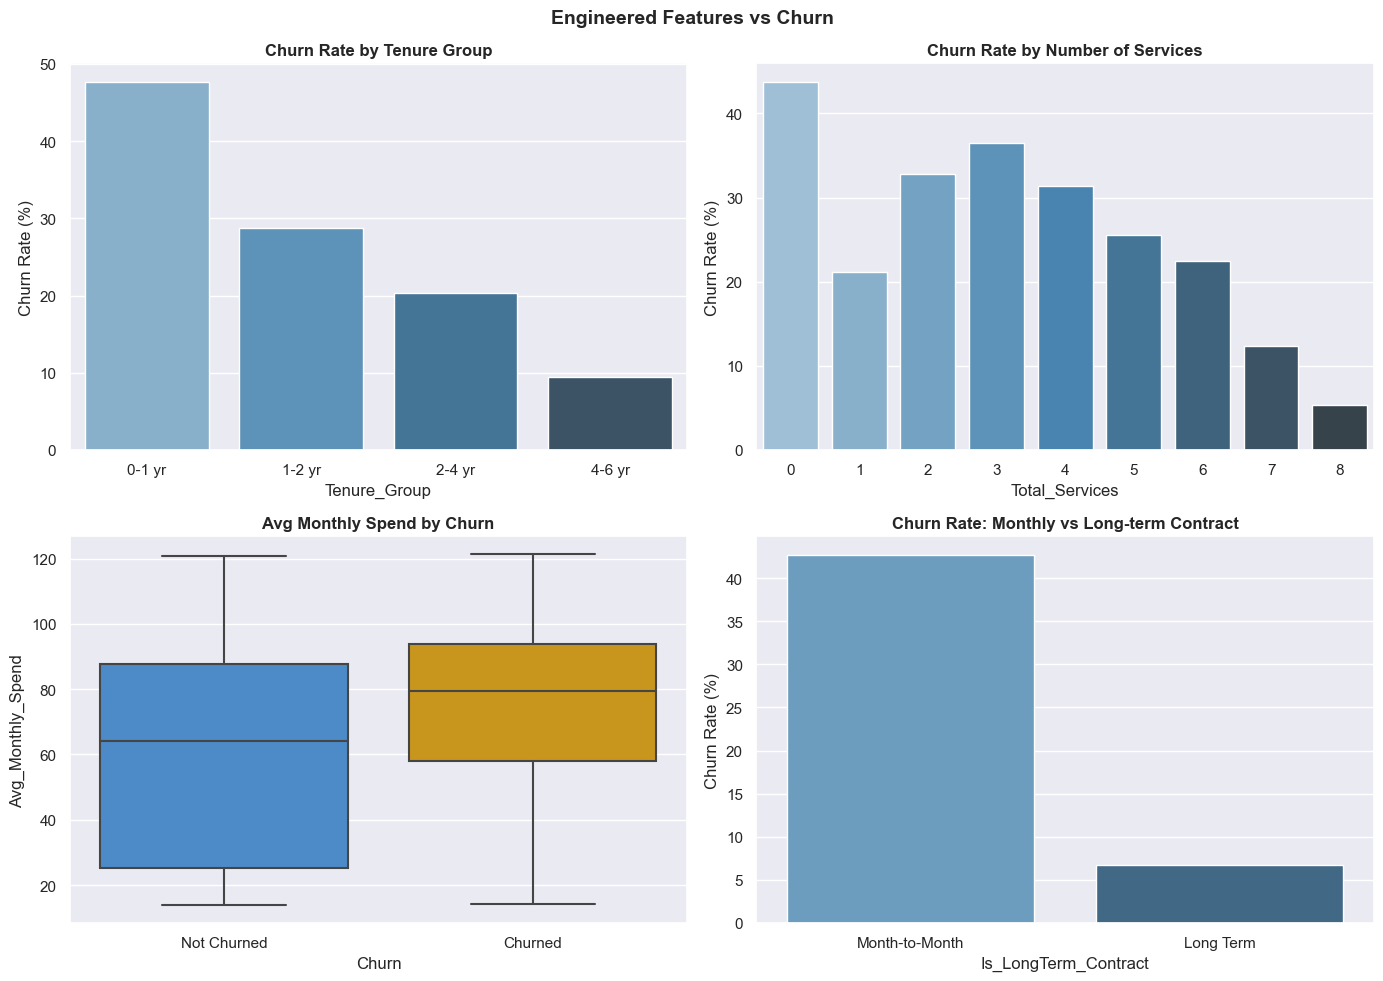

📸 Saved: engineered_features.png



In [27]:
# ============================================================
# 3.2 — Visualize engineered features vs Churn
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Churn rate by Tenure Group
churn_by_tenure = df.groupby('Tenure_Group', observed=True)['Churn']\
    .mean().reset_index()
churn_by_tenure.columns = ['Tenure_Group', 'Churn Rate']
churn_by_tenure['Churn Rate'] *= 100
sns.barplot(x='Tenure_Group', y='Churn Rate',
            data=churn_by_tenure, ax=axes[0,0], palette='Blues_d')
axes[0,0].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')

# Plot 2: Churn rate by Total Services
churn_by_services = df.groupby('Total_Services')['Churn']\
    .mean().reset_index()
churn_by_services['Churn'] *= 100
sns.barplot(x='Total_Services', y='Churn',
            data=churn_by_services, ax=axes[0,1], palette='Blues_d')
axes[0,1].set_title('Churn Rate by Number of Services', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')

# Plot 3: Avg Monthly Spend distribution by Churn
sns.boxplot(x='Churn', y='Avg_Monthly_Spend', data=df,
            palette=['#378ADD', '#E5A000'], ax=axes[1,0])
axes[1,0].set_title('Avg Monthly Spend by Churn', fontweight='bold')
axes[1,0].set_xticklabels(['Not Churned', 'Churned'])

# Plot 4: Churn rate by Contract type
churn_by_contract = df.groupby('Is_LongTerm_Contract')['Churn']\
    .mean().reset_index()
churn_by_contract['Churn'] *= 100
sns.barplot(x='Is_LongTerm_Contract', y='Churn',
            data=churn_by_contract, ax=axes[1,1], palette='Blues_d')
axes[1,1].set_title('Churn Rate: Monthly vs Long-term Contract',
                     fontweight='bold')
axes[1,1].set_xticklabels(['Month-to-Month', 'Long Term'])
axes[1,1].set_ylabel('Churn Rate (%)')

plt.suptitle('Engineered Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('engineered_features.png', dpi=150)
plt.show()
print("📸 Saved: engineered_features.png\n")

In [28]:
# ============================================================
# 3.3 — Rebuild X with new features & rerun pipeline
# ============================================================
print("🔄 Rebuilding X with engineered features...\n")

# Drop target and non-useful columns
X = df.drop(columns=['Churn', 'Tenure_Group'])
y = df['Churn']

# Updated column lists
num_cols = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'Avg_Monthly_Spend', 'Total_Services',
    'Is_LongTerm_Contract', 'Has_Premium_Services'
]

cat_cols = [col for col in X.columns
            if col not in num_cols
            and col != 'SeniorCitizen']

print(f"   Numerical features  ({len(num_cols)}): {num_cols}")
print(f"   Categorical features({len(cat_cols)}): {cat_cols}\n")

🔄 Rebuilding X with engineered features...

   Numerical features  (7): ['tenure', 'MonthlyCharges', 'TotalCharges', 'Avg_Monthly_Spend', 'Total_Services', 'Is_LongTerm_Contract', 'Has_Premium_Services']
   Categorical features(15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']



In [29]:
# ============================================================
# 3.4 — Rebuild pipeline with updated features
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import joblib

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='passthrough')

In [30]:
# ============================================================
# 3.5 — Re-split and reprocess
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

joblib.dump(preprocessor, 'preprocessor.pkl')

print("✅ Pipeline rebuilt with engineered features")
print(f"   X_train_processed shape: {X_train_processed.shape}")
print(f"   X_test_processed shape : {X_test_processed.shape}\n")

✅ Pipeline rebuilt with engineered features
   X_train_processed shape: (5634, 49)
   X_test_processed shape : (1409, 49)



🌲 Running quick feature importance check...



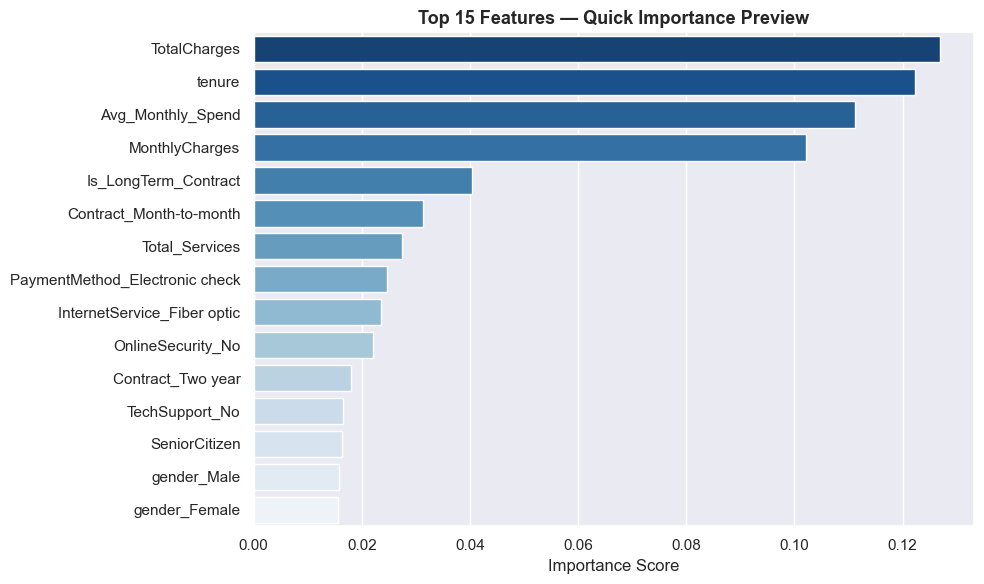

📸 Saved: feature_importance_preview.png



In [31]:
# ============================================================
# 3.6 — Quick feature importance preview
#        (using a lightweight RF to rank features)
# ============================================================
print("🌲 Running quick feature importance check...\n")

rf_quick = RandomForestClassifier(n_estimators=50, random_state=42)
rf_quick.fit(X_train_processed, y_train)

# Get feature names after encoding
ohe_features = preprocessor.named_transformers_['cat']\
    ['encoder'].get_feature_names_out(cat_cols).tolist()
passthrough_features = ['SeniorCitizen']
all_features = num_cols + ohe_features + passthrough_features

importances = pd.Series(
    rf_quick.feature_importances_,
    index=all_features
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title('Top 15 Features — Quick Importance Preview',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_preview.png', dpi=150)
plt.show()
print("📸 Saved: feature_importance_preview.png\n")

In [32]:
# ============================================================
# 3.7 — Step Summary
# ============================================================
print("=" * 50)
print("✅ STEP 3 COMPLETE — Ready to Train Models")
print("=" * 50)
print("  New features added    : 5")
print(f"  Total features (X)    : {X.shape[1]}")
print(f"  Processed features    : {X_train_processed.shape[1]}")
print(f"  Training samples      : {X_train.shape[0]}")
print(f"  Test samples          : {X_test.shape[0]}")
print()
print("  Variables ready for Step 4:")
print("  ✔ X_train_processed, X_test_processed")
print("  ✔ y_train, y_test")
print("  ✔ preprocessor (saved as .pkl)")

✅ STEP 3 COMPLETE — Ready to Train Models
  New features added    : 5
  Total features (X)    : 23
  Processed features    : 49
  Training samples      : 5634
  Test samples          : 1409

  Variables ready for Step 4:
  ✔ X_train_processed, X_test_processed
  ✔ y_train, y_test
  ✔ preprocessor (saved as .pkl)


In [33]:
# ============================================================
# STEP 4 — Train ML Models
# Logistic Regression + Random Forest
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

In [34]:
# ============================================================
# 4.1 — Train Logistic Regression
# ============================================================
print("🔵 Training Logistic Regression...\n")

lr_start = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # handles class imbalance automatically
)
lr_model.fit(X_train_processed, y_train)

lr_time = time.time() - lr_start
lr_preds = lr_model.predict(X_test_processed)
lr_proba = lr_model.predict_proba(X_test_processed)[:, 1]

print(f"   ✅ Logistic Regression trained in {lr_time:.2f} seconds")
print(f"   Accuracy  : {accuracy_score(y_test, lr_preds)*100:.2f}%")
print(f"   Precision : {precision_score(y_test, lr_preds)*100:.2f}%")
print(f"   Recall    : {recall_score(y_test, lr_preds)*100:.2f}%")
print(f"   F1 Score  : {f1_score(y_test, lr_preds)*100:.2f}%")
print(f"   ROC-AUC   : {roc_auc_score(y_test, lr_proba)*100:.2f}%\n")

🔵 Training Logistic Regression...

   ✅ Logistic Regression trained in 0.21 seconds
   Accuracy  : 73.81%
   Precision : 50.43%
   Recall    : 78.34%
   F1 Score  : 61.36%
   ROC-AUC   : 84.17%



In [35]:
# ============================================================
# 4.2 — Train Random Forest
# ============================================================
print("🌲 Training Random Forest...\n")

rf_start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # handles class imbalance
    n_jobs=-1                 # uses all CPU cores = faster
)
rf_model.fit(X_train_processed, y_train)

rf_time = time.time() - rf_start
rf_preds = rf_model.predict(X_test_processed)
rf_proba = rf_model.predict_proba(X_test_processed)[:, 1]

print(f"   ✅ Random Forest trained in {rf_time:.2f} seconds")
print(f"   Accuracy  : {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(f"   Precision : {precision_score(y_test, rf_preds)*100:.2f}%")
print(f"   Recall    : {recall_score(y_test, rf_preds)*100:.2f}%")
print(f"   F1 Score  : {f1_score(y_test, rf_preds)*100:.2f}%")
print(f"   ROC-AUC   : {roc_auc_score(y_test, rf_proba)*100:.2f}%\n")

🌲 Training Random Forest...

   ✅ Random Forest trained in 0.35 seconds
   Accuracy  : 78.35%
   Precision : 61.77%
   Recall    : 48.40%
   F1 Score  : 54.27%
   ROC-AUC   : 82.29%



In [36]:
# ============================================================
# 4.3 — Model Comparison Table
# (this is the "algorithm optimization" your resume mentions)
# ============================================================
print("📊 Model Comparison Table:")

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy (%)':  [
        round(accuracy_score(y_test, lr_preds)*100, 2),
        round(accuracy_score(y_test, rf_preds)*100, 2)
    ],
    'Precision (%)': [
        round(precision_score(y_test, lr_preds)*100, 2),
        round(precision_score(y_test, rf_preds)*100, 2)
    ],
    'Recall (%)':    [
        round(recall_score(y_test, lr_preds)*100, 2),
        round(recall_score(y_test, rf_preds)*100, 2)
    ],
    'F1 Score (%)':  [
        round(f1_score(y_test, lr_preds)*100, 2),
        round(f1_score(y_test, rf_preds)*100, 2)
    ],
    'ROC-AUC (%)':   [
        round(roc_auc_score(y_test, lr_proba)*100, 2),
        round(roc_auc_score(y_test, rf_proba)*100, 2)
    ],
    'Train Time (s)': [
        round(lr_time, 2),
        round(rf_time, 2)
    ]
})

print(comparison.to_string(index=False))
print()

📊 Model Comparison Table:
              Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  ROC-AUC (%)  Train Time (s)
Logistic Regression         73.81          50.43       78.34         61.36        84.17            0.21
      Random Forest         78.35          61.77       48.40         54.27        82.29            0.35



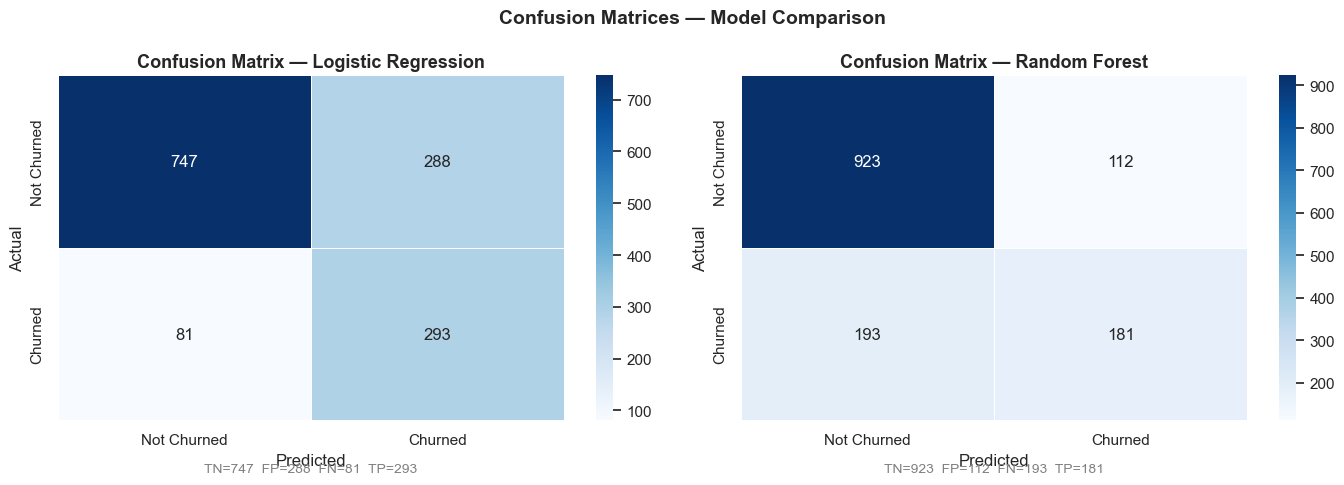

📸 Saved: confusion_matrices.png



In [37]:
# ============================================================
# 4.4 — Confusion Matrices (side by side)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=ax, linewidths=0.5,
        xticklabels=['Not Churned', 'Churned'],
        yticklabels=['Not Churned', 'Churned']
    )
    ax.set_title(f'Confusion Matrix — {title}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Annotate TP, TN, FP, FN
    ax.text(0.5, -0.15,
            f"TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}",
            transform=ax.transAxes, ha='center',
            fontsize=10, color='gray')

plt.suptitle('Confusion Matrices — Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("📸 Saved: confusion_matrices.png\n")

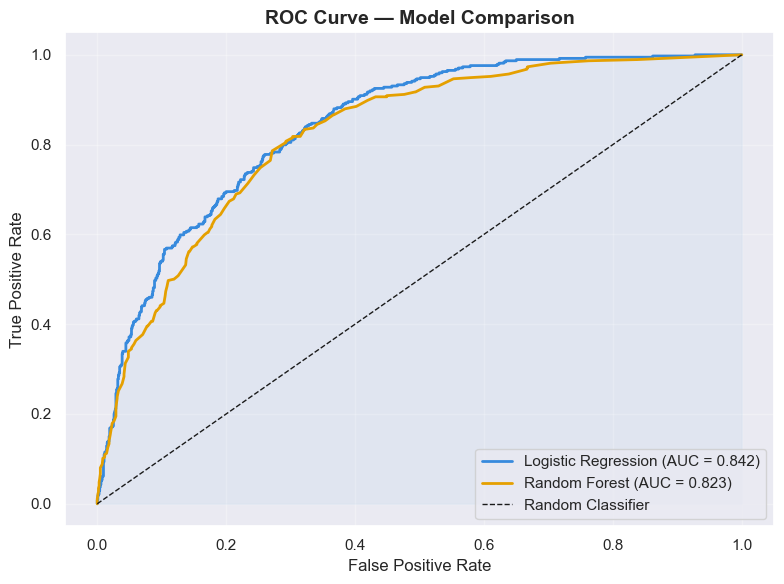

📸 Saved: roc_curves.png



In [38]:
# ============================================================
# 4.5 — ROC Curves (both models on same plot)
# ============================================================
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for proba, label, color in zip(
    [lr_proba, rf_proba],
    ['Logistic Regression', 'Random Forest'],
    ['#378ADD', '#E5A000']
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})',
            color=color, linewidth=2)

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.05, color='#378ADD')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Model Comparison',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("📸 Saved: roc_curves.png\n")

In [39]:
# ============================================================
# 4.6 — Classification Reports
# ============================================================
print("📋 Logistic Regression — Classification Report:")
print(classification_report(y_test, lr_preds,
      target_names=['Not Churned', 'Churned']))

print("📋 Random Forest — Classification Report:")
print(classification_report(y_test, rf_preds,
      target_names=['Not Churned', 'Churned']))

📋 Logistic Regression — Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.90      0.72      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

📋 Random Forest — Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.83      0.89      0.86      1035
     Churned       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [40]:
# ============================================================
# 4.7 — Save both models
# ============================================================
joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')
print("💾 Saved: logistic_regression_model.pkl")
print("💾 Saved: random_forest_model.pkl\n")

💾 Saved: logistic_regression_model.pkl
💾 Saved: random_forest_model.pkl



In [41]:
# ============================================================
# 4.8 — Step Summary
# ============================================================
print("=" * 50)
print("✅ STEP 4 COMPLETE — Models Trained & Evaluated")
print("=" * 50)
lr_f1 = f1_score(y_test, lr_preds)
rf_f1 = f1_score(y_test, rf_preds)
winner = "Random Forest" if rf_f1 > lr_f1 else "Logistic Regression"
print(f"  🏆 Better model so far : {winner}")
print(f"  LR  F1 Score : {lr_f1*100:.2f}%")
print(f"  RF  F1 Score : {rf_f1*100:.2f}%")
print()
print("  Next → Step 5: Hyperparameter Tuning")
print("  Both models will be optimized via GridSearchCV")

✅ STEP 4 COMPLETE — Models Trained & Evaluated
  🏆 Better model so far : Logistic Regression
  LR  F1 Score : 61.36%
  RF  F1 Score : 54.27%

  Next → Step 5: Hyperparameter Tuning
  Both models will be optimized via GridSearchCV


In [42]:
# ============================================================
# STEP 5 — Hyperparameter Tuning
# GridSearchCV (LR) + RandomizedSearchCV (RF)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    cross_val_score, StratifiedKFold
)
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score,
    recall_score, roc_auc_score, classification_report
)

import warnings
warnings.filterwarnings('ignore')


In [43]:
# ============================================================
# 5.1 — Set up Cross Validation Strategy
# ============================================================
# StratifiedKFold keeps churn ratio same in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("⚙️  Cross Validation Strategy:")
print("   StratifiedKFold — 5 folds")
print("   Scoring metric  — F1 Score")
print("   Reason          — imbalanced dataset (26% churn)\n")

⚙️  Cross Validation Strategy:
   StratifiedKFold — 5 folds
   Scoring metric  — F1 Score
   Reason          — imbalanced dataset (26% churn)



In [44]:
# ============================================================
# 5.2 — Hyperparameter Tuning: Logistic Regression
#        Using GridSearchCV (smaller search space = exhaustive)
# ============================================================
print("🔵 Tuning Logistic Regression with GridSearchCV...")
print("   This may take 1-2 minutes...\n")

lr_param_grid = {
    'C':          [0.01, 0.1, 1, 10, 100],
    'solver':     ['liblinear', 'lbfgs'],
    'penalty':    ['l1', 'l2'],
    'max_iter':   [500, 1000]
}

# Note: l1 only works with liblinear solver
# so we filter invalid combos via error_score
lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',
        random_state=42
    ),
    param_grid=lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    error_score=0,   # invalid combos get score 0
    verbose=1
)

lr_start = time.time()
lr_grid.fit(X_train_processed, y_train)
lr_tune_time = time.time() - lr_start

print(f"\n   ✅ GridSearchCV complete in {lr_tune_time:.1f} seconds")
print(f"   Best Parameters : {lr_grid.best_params_}")
print(f"   Best CV F1 Score: {lr_grid.best_score_*100:.2f}%\n")

🔵 Tuning Logistic Regression with GridSearchCV...
   This may take 1-2 minutes...

Fitting 5 folds for each of 40 candidates, totalling 200 fits

   ✅ GridSearchCV complete in 9.6 seconds
   Best Parameters : {'C': 1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
   Best CV F1 Score: 62.93%



In [45]:
# ============================================================
# 5.3 — Hyperparameter Tuning: Random Forest
#        Using RandomizedSearchCV (larger space = random sample)
# ============================================================
print("🌲 Tuning Random Forest with RandomizedSearchCV...")
print("   This may take 2-3 minutes...\n")

rf_param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
    'bootstrap':         [True, False]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=30,         # try 30 random combinations
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_start = time.time()
rf_random.fit(X_train_processed, y_train)
rf_tune_time = time.time() - rf_start

print(f"\n   ✅ RandomizedSearchCV complete in {rf_tune_time:.1f} seconds")
print(f"   Best Parameters : {rf_random.best_params_}")
print(f"   Best CV F1 Score: {rf_random.best_score_*100:.2f}%\n")

🌲 Tuning Random Forest with RandomizedSearchCV...
   This may take 2-3 minutes...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

   ✅ RandomizedSearchCV complete in 67.7 seconds
   Best Parameters : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}
   Best CV F1 Score: 63.33%



In [46]:
# ============================================================
# 5.4 — Evaluate Tuned Models on Test Set
# ============================================================
print("📊 Evaluating tuned models on test set...\n")

# Best models from search
best_lr = lr_grid.best_estimator_
best_rf = rf_random.best_estimator_

# Predictions
lr_preds_tuned = best_lr.predict(X_test_processed)
rf_preds_tuned = best_rf.predict(X_test_processed)
lr_proba_tuned = best_lr.predict_proba(X_test_processed)[:, 1]
rf_proba_tuned = best_rf.predict_proba(X_test_processed)[:, 1]

📊 Evaluating tuned models on test set...



In [47]:
# ============================================================
# 5.5 — Before vs After Tuning Comparison Table
# ============================================================
comparison = pd.DataFrame({
    'Model': [
        'LR — Before Tuning',
        'LR — After Tuning',
        'RF — Before Tuning',
        'RF — After Tuning'
    ],
    'Accuracy (%)': [
        round(accuracy_score(y_test, lr_preds)*100, 2),
        round(accuracy_score(y_test, lr_preds_tuned)*100, 2),
        round(accuracy_score(y_test, rf_preds)*100, 2),
        round(accuracy_score(y_test, rf_preds_tuned)*100, 2)
    ],
    'Precision (%)': [
        round(precision_score(y_test, lr_preds)*100, 2),
        round(precision_score(y_test, lr_preds_tuned)*100, 2),
        round(precision_score(y_test, rf_preds)*100, 2),
        round(precision_score(y_test, rf_preds_tuned)*100, 2)
    ],
    'Recall (%)': [
        round(recall_score(y_test, lr_preds)*100, 2),
        round(recall_score(y_test, lr_preds_tuned)*100, 2),
        round(recall_score(y_test, rf_preds)*100, 2),
        round(recall_score(y_test, rf_preds_tuned)*100, 2)
    ],
    'F1 Score (%)': [
        round(f1_score(y_test, lr_preds)*100, 2),
        round(f1_score(y_test, lr_preds_tuned)*100, 2),
        round(f1_score(y_test, rf_preds)*100, 2),
        round(f1_score(y_test, rf_preds_tuned)*100, 2)
    ],
    'ROC-AUC (%)': [
        round(roc_auc_score(y_test, lr_proba)*100, 2),
        round(roc_auc_score(y_test, lr_proba_tuned)*100, 2),
        round(roc_auc_score(y_test, rf_proba)*100, 2),
        round(roc_auc_score(y_test, rf_proba_tuned)*100, 2)
    ]
})

print("=" * 75)
print(comparison.to_string(index=False))
print("=" * 75)
print()

             Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  ROC-AUC (%)
LR — Before Tuning         73.81          50.43       78.34         61.36        84.17
 LR — After Tuning         73.81          50.43       78.34         61.36        84.17
RF — Before Tuning         78.35          61.77       48.40         54.27        82.29
 RF — After Tuning         75.59          52.87       73.80         61.61        84.09



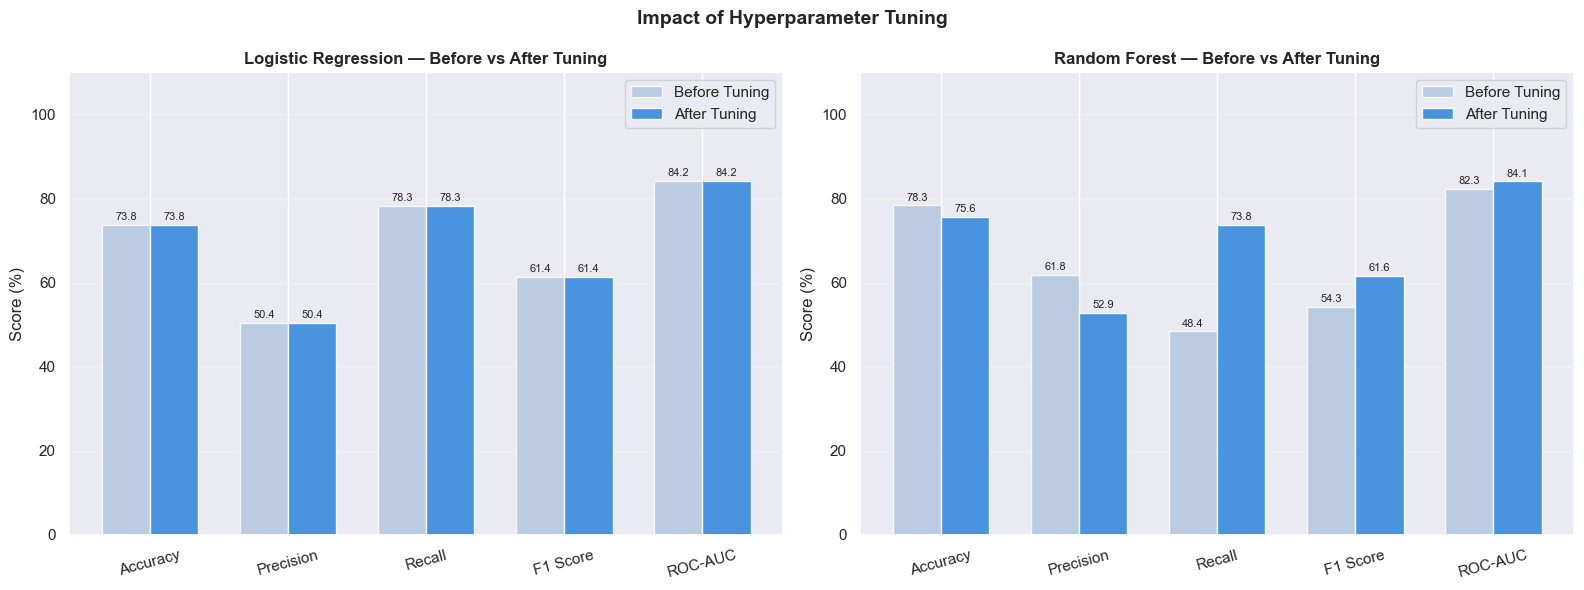

📸 Saved: tuning_comparison.png



In [48]:
# ============================================================
# 5.6 — Visualize Before vs After Tuning
# ============================================================
metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)',
           'F1 Score (%)', 'ROC-AUC (%)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_name, before_idx, after_idx in zip(
    axes,
    ['Logistic Regression', 'Random Forest'],
    [0, 2],
    [1, 3]
):
    before_vals = comparison.iloc[before_idx][metrics].values.astype(float)
    after_vals  = comparison.iloc[after_idx][metrics].values.astype(float)

    x = np.arange(len(metrics))
    width = 0.35

    bars1 = ax.bar(x - width/2, before_vals, width,
                   label='Before Tuning', color='#B0C4DE', alpha=0.8)
    bars2 = ax.bar(x + width/2, after_vals,  width,
                   label='After Tuning',  color='#378ADD', alpha=0.9)

    ax.bar_label(bars1, fmt='%.1f', fontsize=8, padding=2)
    ax.bar_label(bars2, fmt='%.1f', fontsize=8, padding=2)

    ax.set_title(f'{model_name} — Before vs After Tuning',
                 fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (%)', '') for m in metrics],
                       rotation=15)
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, 110)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Impact of Hyperparameter Tuning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_comparison.png', dpi=150)
plt.show()
print("📸 Saved: tuning_comparison.png\n")

In [49]:
# ============================================================
# 5.7 — Cross Validation Scores (tuned models)
# ============================================================
print("🔁 Cross Validation on Tuned Models (5-fold):\n")

for model, name in zip(
    [best_lr, best_rf],
    ['Logistic Regression (Tuned)', 'Random Forest (Tuned)']
):
    cv_scores = cross_val_score(
        model, X_train_processed, y_train,
        cv=cv, scoring='f1', n_jobs=-1
    )
    print(f"   {name}")
    print(f"   CV F1 Scores : {[round(s*100,2) for s in cv_scores]}")
    print(f"   Mean F1      : {cv_scores.mean()*100:.2f}%")
    print(f"   Std Dev      : {cv_scores.std()*100:.2f}%\n")

🔁 Cross Validation on Tuned Models (5-fold):

   Logistic Regression (Tuned)
   CV F1 Scores : [65.78, 58.84, 62.16, 64.72, 63.13]
   Mean F1      : 62.93%
   Std Dev      : 2.40%

   Random Forest (Tuned)
   CV F1 Scores : [64.24, 60.52, 63.11, 64.34, 64.42]
   Mean F1      : 63.33%
   Std Dev      : 1.48%



In [50]:
# ============================================================
# 5.8 — Pick & Save the Best Final Model
# ============================================================
lr_f1_tuned = f1_score(y_test, lr_preds_tuned)
rf_f1_tuned = f1_score(y_test, rf_preds_tuned)

if rf_f1_tuned >= lr_f1_tuned:
    best_model       = best_rf
    best_model_name  = "Random Forest (Tuned)"
    best_preds       = rf_preds_tuned
    best_proba       = rf_proba_tuned
else:
    best_model       = best_lr
    best_model_name  = "Logistic Regression (Tuned)"
    best_preds       = lr_preds_tuned
    best_proba       = lr_proba_tuned

joblib.dump(best_lr, 'best_lr_tuned.pkl')
joblib.dump(best_rf, 'best_rf_tuned.pkl')
joblib.dump(best_model, 'best_final_model.pkl')

print("💾 Saved: best_lr_tuned.pkl")
print("💾 Saved: best_rf_tuned.pkl")
print("💾 Saved: best_final_model.pkl\n")

💾 Saved: best_lr_tuned.pkl
💾 Saved: best_rf_tuned.pkl
💾 Saved: best_final_model.pkl



In [51]:
# ============================================================
# 5.9 — Step Summary
# ============================================================
print("=" * 50)
print("✅ STEP 5 COMPLETE — Hyperparameter Tuning Done")
print("=" * 50)
print(f"  🏆 Best Final Model : {best_model_name}")
print(f"  LR F1 (tuned)       : {lr_f1_tuned*100:.2f}%")
print(f"  RF F1 (tuned)       : {rf_f1_tuned*100:.2f}%")
print()
print("  Next → Step 6: Feature Importance + Final Visuals")

✅ STEP 5 COMPLETE — Hyperparameter Tuning Done
  🏆 Best Final Model : Random Forest (Tuned)
  LR F1 (tuned)       : 61.36%
  RF F1 (tuned)       : 61.61%

  Next → Step 6: Feature Importance + Final Visuals


In [52]:
# ============================================================
# STEP 6 — Feature Importance + Final Visualizations
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.metrics import (
    confusion_matrix, roc_curve,
    roc_auc_score, precision_recall_curve,
    average_precision_score
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

In [53]:
# ============================================================
# 6.1 — Get Feature Names after preprocessing
# ============================================================
print("📋 Extracting feature names...\n")

ohe_features = preprocessor\
    .named_transformers_['cat']['encoder']\
    .get_feature_names_out(cat_cols).tolist()

passthrough_features = ['SeniorCitizen']
all_features = num_cols + ohe_features + passthrough_features

print(f"   Total features after encoding: {len(all_features)}")
print(f"   Numerical : {len(num_cols)}")
print(f"   Encoded   : {len(ohe_features)}")
print(f"   Passthrough: {len(passthrough_features)}\n")

📋 Extracting feature names...

   Total features after encoding: 49
   Numerical : 7
   Encoded   : 41
   Passthrough: 1



In [54]:
# ============================================================
# 6.2 — Random Forest Feature Importance
# ============================================================
print("🌲 Extracting Random Forest feature importances...\n")

rf_importances = pd.Series(
    best_rf.feature_importances_,
    index=all_features
).sort_values(ascending=False)

top15 = rf_importances.head(15)
bottom5 = rf_importances.tail(5)

print("   Top 5 most important features:")
for feat, score in top15.head(5).items():
    print(f"   → {feat:<35} {score:.4f}")
print()


🌲 Extracting Random Forest feature importances...

   Top 5 most important features:
   → tenure                              0.0983
   → Contract_Month-to-month             0.0915
   → Is_LongTerm_Contract                0.0865
   → TotalCharges                        0.0819
   → MonthlyCharges                      0.0547



In [55]:
# ============================================================
# 6.3 — Logistic Regression Coefficients
# ============================================================
print("🔵 Extracting Logistic Regression coefficients...\n")

lr_coefficients = pd.Series(
    np.abs(best_lr.coef_[0]),
    index=all_features
).sort_values(ascending=False)

top15_lr = lr_coefficients.head(15)

🔵 Extracting Logistic Regression coefficients...



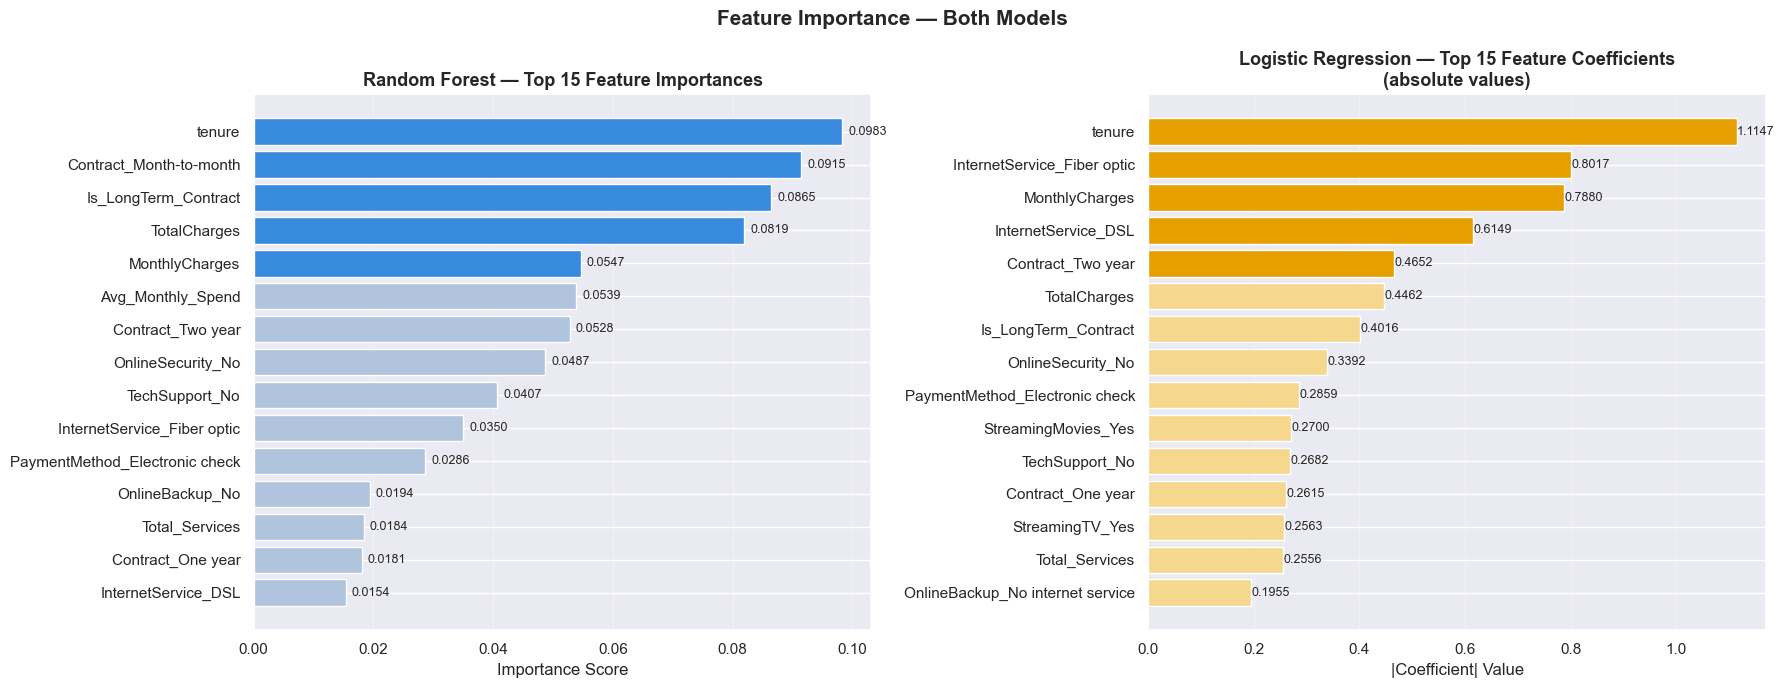

📸 Saved: feature_importance_final.png



In [56]:
# ============================================================
# 6.4 — Plot: RF Feature Importance (Top 15)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# RF importance
colors_rf = ['#378ADD' if i < 5 else '#B0C4DE'
             for i in range(len(top15))]
axes[0].barh(top15.index[::-1], top15.values[::-1],
             color=colors_rf[::-1])
axes[0].set_title('Random Forest — Top 15 Feature Importances',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, (val, name) in enumerate(
        zip(top15.values[::-1], top15.index[::-1])):
    axes[0].text(val + 0.001, i, f'{val:.4f}',
                 va='center', fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# LR coefficients
colors_lr = ['#E5A000' if i < 5 else '#F5D78E'
             for i in range(len(top15_lr))]
axes[1].barh(top15_lr.index[::-1], top15_lr.values[::-1],
             color=colors_lr[::-1])
axes[1].set_title('Logistic Regression — Top 15 Feature Coefficients\n'
                  '(absolute values)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('|Coefficient| Value')
for i, (val, name) in enumerate(
        zip(top15_lr.values[::-1], top15_lr.index[::-1])):
    axes[1].text(val + 0.001, i, f'{val:.4f}',
                 va='center', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance — Both Models',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_final.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("📸 Saved: feature_importance_final.png\n")

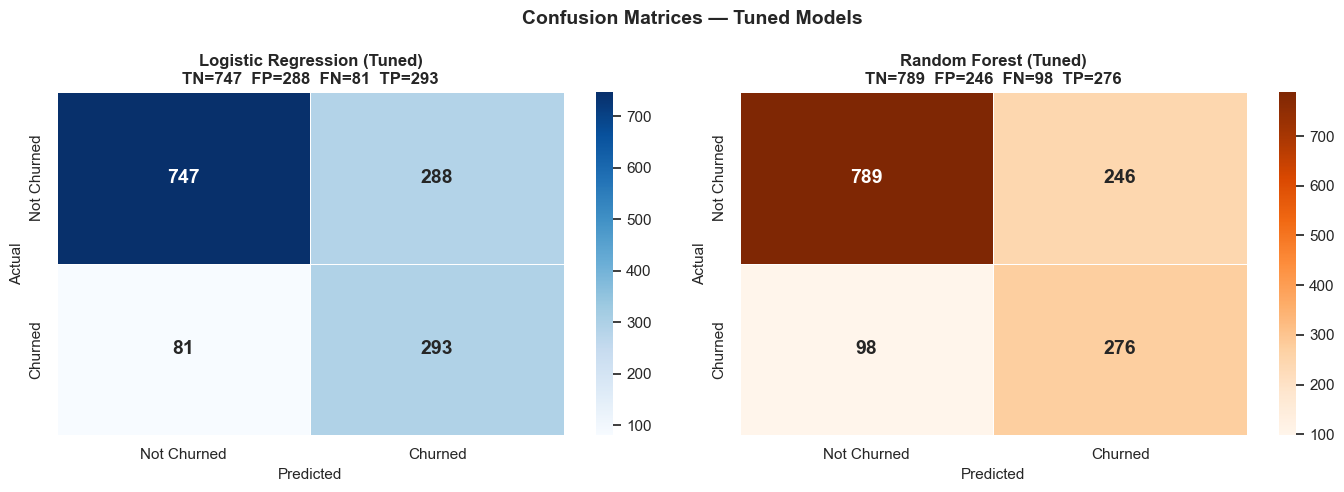

📸 Saved: confusion_matrices_tuned.png



In [57]:
# ============================================================
# 6.5 — Final Confusion Matrices (Tuned Models)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title, color in zip(
    axes,
    [lr_preds_tuned, rf_preds_tuned],
    ['Logistic Regression (Tuned)', 'Random Forest (Tuned)'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color,
        ax=ax, linewidths=0.5,
        xticklabels=['Not Churned', 'Churned'],
        yticklabels=['Not Churned', 'Churned'],
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{title}\n'
        f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrices — Tuned Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_tuned.png', dpi=150)
plt.show()
print("📸 Saved: confusion_matrices_tuned.png\n")

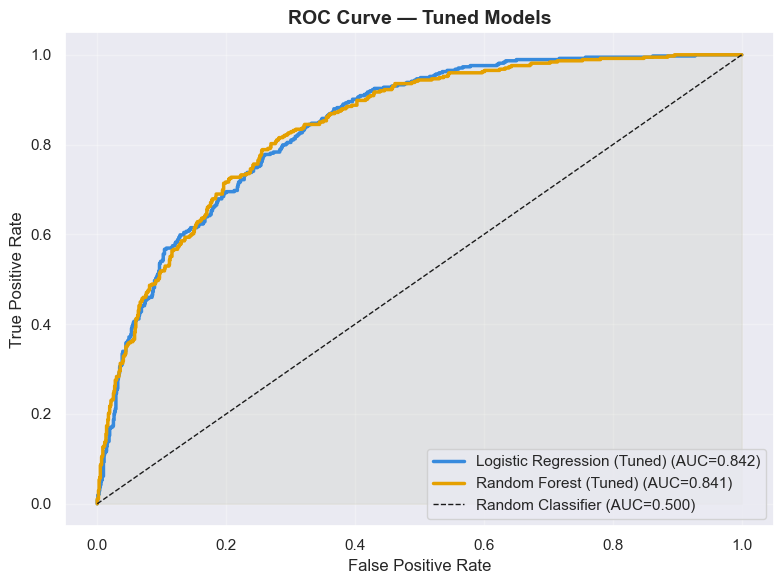

📸 Saved: roc_curves_tuned.png



In [58]:
# ============================================================
# 6.6 — ROC Curves (Tuned Models)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for proba, label, color in zip(
    [lr_proba_tuned, rf_proba_tuned],
    ['Logistic Regression (Tuned)', 'Random Forest (Tuned)'],
    ['#378ADD', '#E5A000']
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr,
            label=f'{label} (AUC={auc:.3f})',
            color=color, linewidth=2.5)
    ax.fill_between(fpr, tpr, alpha=0.05, color=color)

ax.plot([0,1], [0,1], 'k--', linewidth=1,
        label='Random Classifier (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Tuned Models',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_tuned.png', dpi=150)
plt.show()
print("📸 Saved: roc_curves_tuned.png\n")

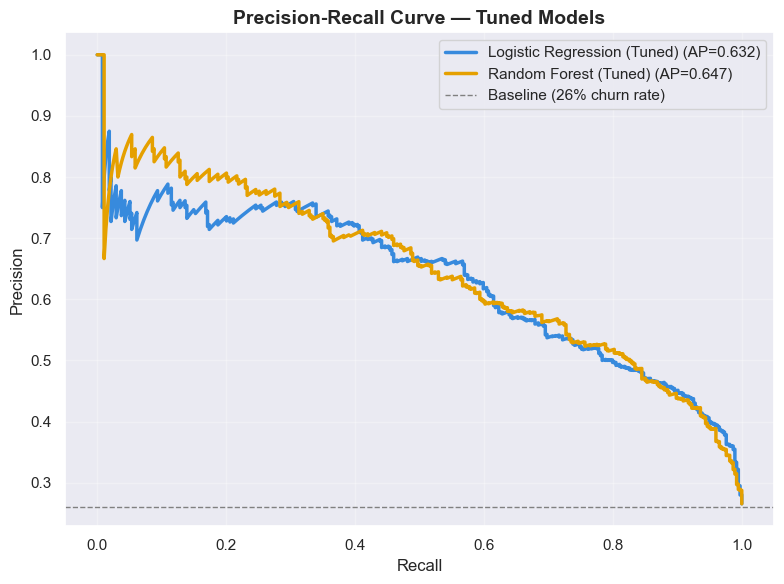

📸 Saved: precision_recall_curve.png



In [59]:
# ============================================================
# 6.7 — Precision-Recall Curve
# (better metric for imbalanced datasets)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for proba, label, color in zip(
    [lr_proba_tuned, rf_proba_tuned],
    ['Logistic Regression (Tuned)', 'Random Forest (Tuned)'],
    ['#378ADD', '#E5A000']
):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall, precision,
            label=f'{label} (AP={ap:.3f})',
            color=color, linewidth=2.5)

ax.axhline(y=0.26, color='gray', linestyle='--',
           linewidth=1, label='Baseline (26% churn rate)')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Tuned Models',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150)
plt.show()
print("📸 Saved: precision_recall_curve.png\n")

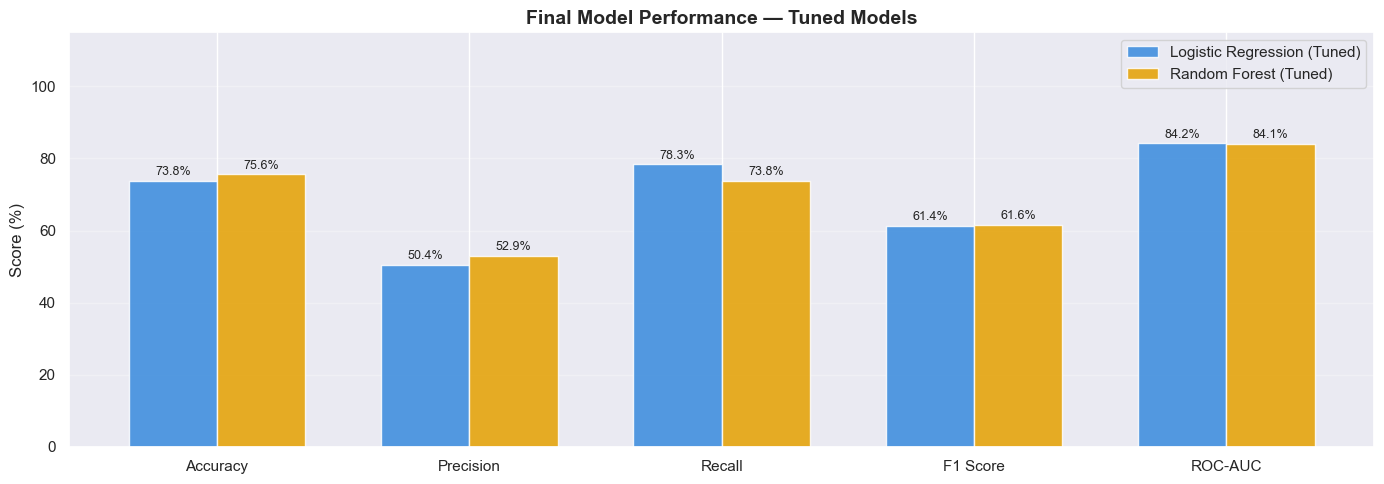

📸 Saved: final_model_summary.png



In [60]:
# ============================================================
# 6.8 — Final Model Summary Dashboard
# ============================================================
fig = plt.figure(figsize=(14, 5))

metrics_names = ['Accuracy', 'Precision', 'Recall',
                 'F1 Score', 'ROC-AUC']

lr_scores = [
    accuracy_score(y_test,  lr_preds_tuned),
    precision_score(y_test, lr_preds_tuned),
    recall_score(y_test,    lr_preds_tuned),
    f1_score(y_test,        lr_preds_tuned),
    roc_auc_score(y_test,   lr_proba_tuned)
]

rf_scores = [
    accuracy_score(y_test,  rf_preds_tuned),
    precision_score(y_test, rf_preds_tuned),
    recall_score(y_test,    rf_preds_tuned),
    f1_score(y_test,        rf_preds_tuned),
    roc_auc_score(y_test,   rf_proba_tuned)
]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = plt.bar(x - width/2, [s*100 for s in lr_scores],
                width, label='Logistic Regression (Tuned)',
                color='#378ADD', alpha=0.85)
bars2 = plt.bar(x + width/2, [s*100 for s in rf_scores],
                width, label='Random Forest (Tuned)',
                color='#E5A000', alpha=0.85)

plt.bar_label(bars1, fmt='%.1f%%', fontsize=9, padding=2)
plt.bar_label(bars2, fmt='%.1f%%', fontsize=9, padding=2)

plt.title('Final Model Performance — Tuned Models',
          fontsize=14, fontweight='bold')
plt.xticks(x, metrics_names, fontsize=11)
plt.ylabel('Score (%)')
plt.ylim(0, 115)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_model_summary.png', dpi=150)
plt.show()
print("📸 Saved: final_model_summary.png\n")

In [61]:
# ============================================================
# 6.9 — Print Final Verdict
# ============================================================
lr_f1 = f1_score(y_test, lr_preds_tuned)
rf_f1 = f1_score(y_test, rf_preds_tuned)
winner = "Random Forest" if rf_f1 >= lr_f1 else "Logistic Regression"

print("=" * 55)
print("✅ STEP 6 COMPLETE — All Visualizations Saved")
print("=" * 55)
print(f"  🏆 Best Model         : {winner}")
print(f"  LR  F1 (tuned)        : {lr_f1*100:.2f}%")
print(f"  RF  F1 (tuned)        : {rf_f1*100:.2f}%")
print()
print("  📸 Plots saved:")
print("     ✔ feature_importance_final.png")
print("     ✔ confusion_matrices_tuned.png")
print("     ✔ roc_curves_tuned.png")
print("     ✔ precision_recall_curve.png")
print("     ✔ final_model_summary.png")
print()

✅ STEP 6 COMPLETE — All Visualizations Saved
  🏆 Best Model         : Random Forest
  LR  F1 (tuned)        : 61.36%
  RF  F1 (tuned)        : 61.61%

  📸 Plots saved:
     ✔ feature_importance_final.png
     ✔ confusion_matrices_tuned.png
     ✔ roc_curves_tuned.png
     ✔ precision_recall_curve.png
     ✔ final_model_summary.png



In [62]:
# ============================================================
# STEP 7 — Save Model & Prepare for GitHub
# ============================================================

import joblib
import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

In [63]:
# ============================================================
# 7.1 — Save all models & artifacts
# ============================================================
print("💾 Saving all models and artifacts...\n")

# Save models
joblib.dump(best_lr,        'best_lr_tuned.pkl')
joblib.dump(best_rf,        'best_rf_tuned.pkl')
joblib.dump(best_model,     'best_final_model.pkl')
joblib.dump(preprocessor,   'preprocessor.pkl')

print("   ✅ best_lr_tuned.pkl")
print("   ✅ best_rf_tuned.pkl")
print("   ✅ best_final_model.pkl")
print("   ✅ preprocessor.pkl")

# Save model metadata as JSON
model_metadata = {
    "project"       : "Customer Churn Prediction",
    "best_model"    : best_model_name,
    "best_params_lr": lr_grid.best_params_,
    "best_params_rf": rf_random.best_params_,
    "test_metrics"  : {
        "logistic_regression": {
            "accuracy" : round(accuracy_score(y_test, lr_preds_tuned), 4),
            "precision": round(precision_score(y_test, lr_preds_tuned), 4),
            "recall"   : round(recall_score(y_test, lr_preds_tuned), 4),
            "f1_score" : round(f1_score(y_test, lr_preds_tuned), 4),
            "roc_auc"  : round(roc_auc_score(y_test, lr_proba_tuned), 4)
        },
        "random_forest": {
            "accuracy" : round(accuracy_score(y_test, rf_preds_tuned), 4),
            "precision": round(precision_score(y_test, rf_preds_tuned), 4),
            "recall"   : round(recall_score(y_test, rf_preds_tuned), 4),
            "f1_score" : round(f1_score(y_test, rf_preds_tuned), 4),
            "roc_auc"  : round(roc_auc_score(y_test, rf_proba_tuned), 4)
        }
    },
    "dataset_info": {
        "rows"       : 7043,
        "features"   : X.shape[1],
        "churn_rate" : "26.5%",
        "train_split": "80%",
        "test_split" : "20%"
    }
}

with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=4)
print("   ✅ model_metadata.json\n")

💾 Saving all models and artifacts...

   ✅ best_lr_tuned.pkl
   ✅ best_rf_tuned.pkl
   ✅ best_final_model.pkl
   ✅ preprocessor.pkl
   ✅ model_metadata.json



In [64]:
# ============================================================
# 7.2 — Print final model performance one last time
# ============================================================
lr_f1  = f1_score(y_test, lr_preds_tuned)
rf_f1  = f1_score(y_test, rf_preds_tuned)
lr_auc = roc_auc_score(y_test, lr_proba_tuned)
rf_auc = roc_auc_score(y_test, rf_proba_tuned)

print("=" * 55)
print("🏆 FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  {'Metric':<20} {'LR (Tuned)':>15} {'RF (Tuned)':>15}")
print("-" * 55)
print(f"  {'Accuracy':<20} "
      f"{accuracy_score(y_test, lr_preds_tuned)*100:>14.2f}% "
      f"{accuracy_score(y_test, rf_preds_tuned)*100:>14.2f}%")
print(f"  {'Precision':<20} "
      f"{precision_score(y_test, lr_preds_tuned)*100:>14.2f}% "
      f"{precision_score(y_test, rf_preds_tuned)*100:>14.2f}%")
print(f"  {'Recall':<20} "
      f"{recall_score(y_test, lr_preds_tuned)*100:>14.2f}% "
      f"{recall_score(y_test, rf_preds_tuned)*100:>14.2f}%")
print(f"  {'F1 Score':<20} "
      f"{lr_f1*100:>14.2f}% "
      f"{rf_f1*100:>14.2f}%")
print(f"  {'ROC-AUC':<20} "
      f"{lr_auc*100:>14.2f}% "
      f"{rf_auc*100:>14.2f}%")
print("-" * 55)
print(f"  🏆 Best Model: {best_model_name}")
print("=" * 55)
print()

🏆 FINAL MODEL PERFORMANCE SUMMARY
  Metric                    LR (Tuned)      RF (Tuned)
-------------------------------------------------------
  Accuracy                      73.81%          75.59%
  Precision                     50.43%          52.87%
  Recall                        78.34%          73.80%
  F1 Score                      61.36%          61.61%
  ROC-AUC                       84.17%          84.09%
-------------------------------------------------------
  🏆 Best Model: Random Forest (Tuned)

